# Desventajas de los árboles de decisión

## Desventaja 1: son propensos a tener sobre-ajuste

Como lo hemos visto a lo largo de las lecciones anteriores los árboles de decisión tienen a tener sobre-ajuste.

Esto se debe a que el algoritmo CART busca generar particiones hasta generar **nodos lo más homogéneos posibles**. Y si tenemos muchos datos y múltiples características estas particiones podrían incluso llegar al punto de generar hojas con muy pocos datos, dando origen precisamente al fenómeno de *overfitting*:

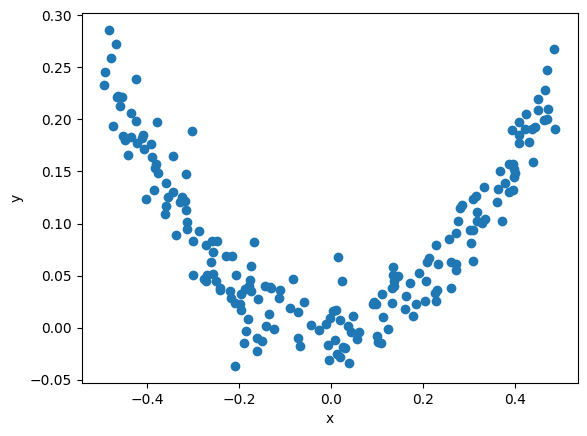

In [2]:
# Leamos el set de datos "xy_regresion"
import numpy as np
import matplotlib.pyplot as plt

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/28-2024-10-ArbolesDeDecision/data/'
datos = np.load(RUTA + 'xy_regresion.npz')
x = datos['X'] # Característica
y = datos['Y'] # Variable a predecir

# Y generemos un gráfico simple
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y');

Y supongamos que ahora construimos un árbol SIN RESTRICCIONES que tome la única característica ("x") e intente predecir el valor "y":

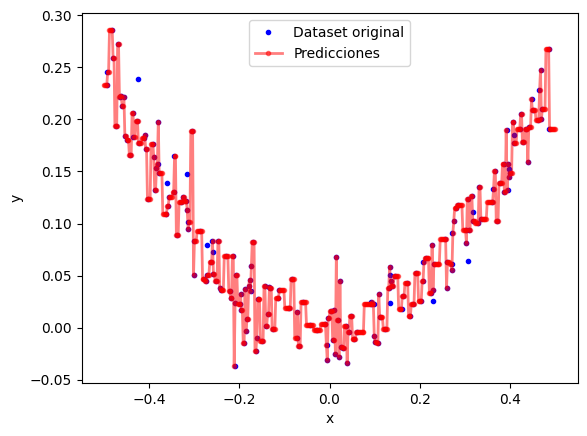

In [3]:
from sklearn.tree import DecisionTreeRegressor

arbol_reg = DecisionTreeRegressor(random_state=123)
arbol_reg.fit(x,y)

# Generemos predicciones con el árbol anterior
x1 = np.linspace(-0.5, 0.5, 500).reshape(-1,1)
ypred1 = arbol_reg.predict(x1)

# Y dibujemos estas predicciones superpuestas al dataset original para ver el overfitting
plt.plot(x, y, 'b.', label='Dataset original')
plt.plot(x1, ypred1, 'r.-', linewidth=2, alpha=0.5, label='Predicciones')
plt.xlabel("x")
plt.ylabel('y')
plt.legend(loc='upper center')

Desde luego, podemos reducir este *overfitting* usando cualquiera de las técnicas vistas en el módulo anterior (poda o ajuste de hiper-parámetros) pero lo importante acá es que **por naturaleza un árbol de decisión tiende a tener sobre-ajuste**.

## Desventaja 2: son muy sensibles a ligeras variaciones en la distribución de los datos

Supongamos que tenemos el dataset "xy_clasificacion.npz":

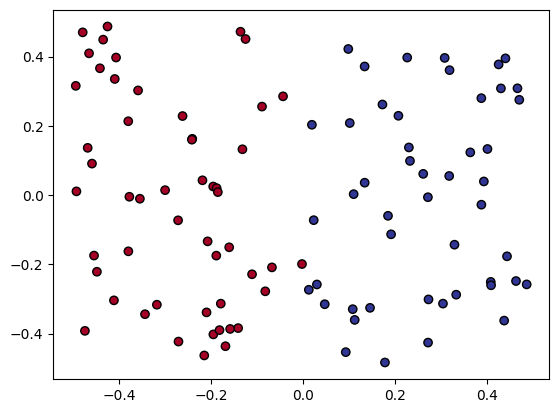

In [4]:
datos = np.load(RUTA + 'xy_clasificacion.npz')
x = datos['X'] # Características
y = datos['Y'] # Variable a predecir (categoría)

plt.scatter(x[:, 0], x[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu);

Y supongamos que construimos un sencillo árbol de clasificación entrenado con este set de datos:

In [5]:
from sklearn.tree import DecisionTreeClassifier

arbol_clf_1 = DecisionTreeClassifier(random_state=123)
arbol_clf_1.fit(x,y)

DecisionTreeClassifier(random_state=123)

Creemos una sencilla función que nos permita visualizar las fronteras de decisión (es decir las particiones del espacio de características) de este árbol:

In [7]:
def graficar_frontera_decision(tree, X, ax, titulo):
    # Límites del gráfico
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Generar grilla para calcular predicciones
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    # Obtener predicciones con el árbol entrenado
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Generar gráfico usando "contourf" para dibujar con
    # diferentes colores cada región obtenida tras la partición
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    ax.scatter(x[:, 0], x[:, 1], c=y, edgecolor='k', cmap=plt.cm.RdYlBu)

    # Ajustar límites ejes de la gráfica
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

    # Añadir título
    ax.set_title(titulo)

Y usemos esta función para graficar las fronteras de decisión de este primer árbol:

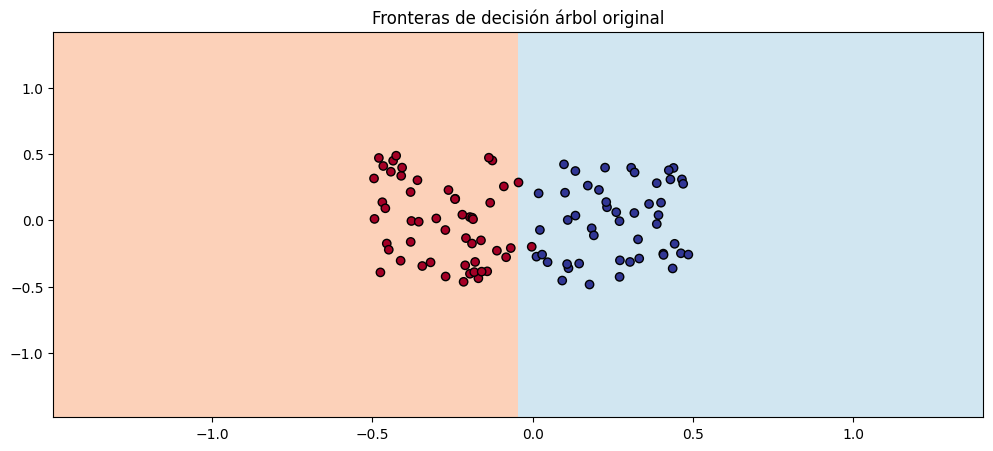

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
graficar_frontera_decision(arbol_clf_1, x, ax, 'Fronteras de decisión árbol original')

Y ahora supongamos que tenemos un segundo set de datos ("xy_clasificacion_rotado.npz") muy similar al anterior pero ligeramente rotado:

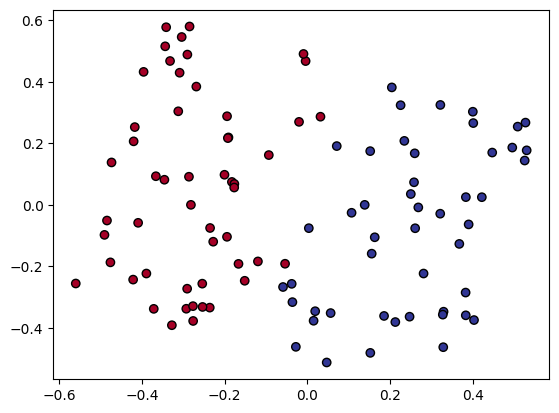

In [9]:
datos = np.load(RUTA + 'xy_clasificacion_rotado.npz')
x_r = datos['X'] # Características
y_r = datos['Y'] # Variable a predecir (categoría)

plt.scatter(x_r[:, 0], x_r[:, 1], c=y_r, edgecolor='k', cmap=plt.cm.RdYlBu);

En principio las diferencias son mínimas pero resultarán siendo significativas en términos de las fronteras de decisión obtenidas.

Entrenemos un segundo árbol de clasificación con este dataset:

In [10]:
arbol_clf_2 = DecisionTreeClassifier(random_state=123)
arbol_clf_2.fit(x_r,y_r)

DecisionTreeClassifier(random_state=123)

Y ahora generemos dos gráficos de la frontera de decisión: a la izquierda estará la del árbol original y a la derecha la de este segundo árbol:

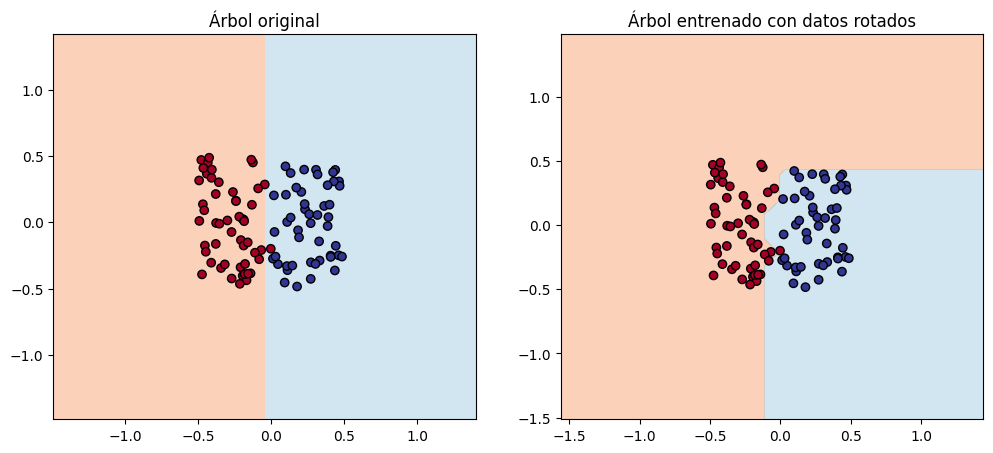

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

graficar_frontera_decision(arbol_clf_1, x, axes[0], "Árbol original")
graficar_frontera_decision(arbol_clf_2, x_r, axes[1], "Árbol entrenado con datos rotados")

Las diferencias entre un set de datos y el otro son casi imperceptibles. Sin embargo, no lo son para el algoritmo CART que a pesar de clasificar correctamente lo datos, ha generado fronteras de decisión totalmente diferentes al comparar los dos árboles.

Este comportamiento está muy relacionado con la desventaja analizada anteriormente ("overfitting") pues las diferentes particiones se calculan analizando cada característica por aparte y calculando los umbrales con base en cada uno de los puntos del set de datos, lo que puede originar árboles demasiado complejos para el set de datos que se esté analizando.

## Cuándo es recomendable usar árboles de decisión

1. Cuando queremos contar con un modelo interpretable y relativamente simple
2. Cuando tengamos sets de datos relativamente "pequeños" (unos cuantos cientos o de miles de datos). Con sets de datos más grandes incrementamos el riesgo de "overfitting"

Cuando nuestro set de datos sea más complejo (más características, más datos) o la interpretabilidad no sea un requisito podemos usar modelos más sofisticados, entre los cuales se cuentan los **Bosques Aleatorios** que serán el tema del próximo curso.